# Custom Vision Partitioners

> Any custom vision paritioner that is not a built-in paritioner in flower-dataset library.


In [ ]:
#| default_exp data.vision.partitioners

In [ ]:
#| hide
from nbdev.showdoc import *

In [ ]:
#| export
import numpy as np
from fastcore.utils import *
import numpy as np
from flwr_datasets.partitioner import Partitioner


## Rotated and Masked MNIST


In [ ]:
#| export
class RotatedPatchedPartitioner(Partitioner):
    def __init__(self, num_partitions=40, num_rotations=4, patch_size=2, seed=42):
        super().__init__()
        self._num_partitions = num_partitions
        self.num_rotations = num_rotations
        self.patch_size = patch_size
        self.noise_levels = [0.0, 0.15, 0.30, 0.50]
        self.root_seed = int((np.e ** np.euler_gamma) ** np.pi * 1000)
        self.seed = self.root_seed

    @property
    def num_partitions(self) -> int:
        return self._num_partitions

    def load_partition(self, partition_id: int):
        dataset = self.dataset
        total_len = len(dataset)
        
        # 1. Standard Slicing
        samples_per_client = total_len // self._num_partitions
        start_idx = partition_id * samples_per_client
        end_idx = (partition_id + 1) * samples_per_client
        partition = dataset.select(range(start_idx, end_idx))
        
        # 2. Define the clusters seen in the paper (Figure A1)
        # We map partition_id to one of 4 clusters
        num_clusters = 4
        clients_per_cluster = self._num_partitions // num_clusters
        cluster_idx = partition_id // clients_per_cluster
        
        # 3. Assign rotation and noise based on the cluster index
        # Cluster 1: 0°, 0% Masked
        # Cluster 2: 90°, 0% Masked 
        # Cluster 3: 180°, 15% Masked
        # Cluster 4: 270°, 30-50% Masked (we can alternate or use partition_id for variety)
        
        rotations = [0, 1, 2, 3] # k values for 0, 90, 180, 270 degrees
        rotation_k = rotations[cluster_idx]
        
        # Map clusters to noise levels as per Figure A1
        if cluster_idx == 0: # Cluster 1
            current_noise = 0.0
        elif cluster_idx == 1: # Cluster 2
            current_noise = 0.0
        elif cluster_idx == 2: # Cluster 3
            current_noise = 0.15
        else: # Cluster 4 (Alternating 30% and 50% for high noise variety)
            current_noise = 0.30 if (partition_id % 2 == 0) else 0.50

        # 4. Generate the silo-specific mask
        if self.patch_size > 0 and current_noise > 0:
            # Pass current_noise to the mask generator
            mask = self._generate_mask(partition_id, current_noise)
        else:
            # Return a zero mask if no noise is applied
            mask = np.zeros((28, 28), dtype=np.float32)

        print(f"Partition {partition_id}: Cluster {cluster_idx + 1}, "
            f"Rot: {rotation_k * 90}°, Noise: {current_noise * 100}%")
        
        # 5. Attach metadata for the VisionBlock transform
        partition.rotation_k = rotation_k
        partition.silo_mask = mask
        partition.noise_level = current_noise # Useful for logging
        
        return partition
    
    def _generate_mask(self, p_id, noise_level):
        # Authors use a seed based on the root_seed + silo_id for intra-cluster diff
        rand = np.random.default_rng(seed=self.root_seed + p_id)
        w, h = 28, 28
        
        # Determine grid size for patches
        grid_w = int(np.ceil(w / self.patch_size))
        grid_h = int(np.ceil(h / self.patch_size))
        
        # Create mask: 1 is a white patch, 0 is original data
        mask_grid = rand.choice([0, 1], size=(grid_w, grid_h), 
                                p=[1 - noise_level, noise_level])
        
        # Upscale to 28x28
        noise_patch = np.kron(mask_grid, np.ones((self.patch_size, self.patch_size)))
        return noise_patch[:w, :h] # Crop to exact MNIST size
    

In [ ]:
#| hide
from flwr_datasets import FederatedDataset

partitioner = RotatedPatchedPartitioner(num_partitions=40, patch_size= 0)
test_partitioner = RotatedPatchedPartitioner(num_partitions=40, patch_size= 0)
fds = FederatedDataset(
    dataset="ylecun/mnist", 
    partitioners={"train": partitioner, "test": test_partitioner}
)

Partition 20: Cluster 3, Rot: 180°, Noise: 15.0%


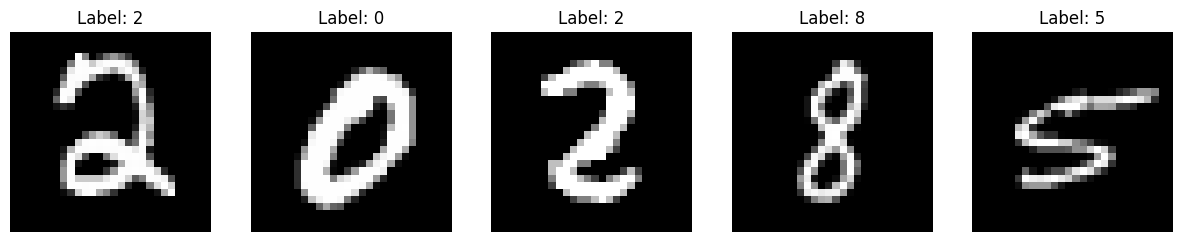

In [ ]:
#| hide
import matplotlib.pyplot as plt
def plot_client_samples(partition, num_samples=5):
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    for i in range(num_samples):
        img = np.array(partition[i]['image']).squeeze()  # Remove channel dimension if present
        label = partition[i]['label']
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"Label: {label}")
        axes[i].axis('off')
    plt.show()

idx = np.random.randint(0, fds.partitioners["train"].num_partitions)
client_data = fds.load_partition(idx, "train")
plot_client_samples(client_data, num_samples=5)

In [ ]:
#| hide
import nbdev
nbdev.nbdev_export()